In [12]:
# pakiety i struktury danych
using Pkg
Pkg.activate(".")
using GLMakie, BenchmarkTools, Random, Plots

struct SimParams
    K_local::Int64    
    p_pass::Float64   
    r_prey::Float64   
    alpha::Float64    
    d_pred::Float64   
end

mutable struct GridState
    prey::Matrix{Int64}
    pred::Matrix{Int64}
    pred_energy::Matrix{Float64} 
    terrain::Matrix{Int64} 
end

println("Struktury załadowane.")

  Activating project at `c:\Users\user\Desktop\obliczenia naukowe\obliczenia_naukowe`


Struktury załadowane.


In [13]:
#funkcja obliczeniowa
function get_local_prey_density(prey::Matrix{Int64}, i::Int, j::Int, rows::Int, cols::Int)::Int
    count = 0
    for dj in -2:2, di in -2:2
        ni, nj = i + di, j + dj
        if (1 <= ni <= rows) && (1 <= nj <= cols)
            @inbounds count += prey[ni, nj]
        end
    end
    return count
end

function update_sim!(next_state::GridState, curr_state::GridState, p::SimParams)
    R, C = size(curr_state.prey)
    fill!(next_state.prey, 0)
    fill!(next_state.pred, 0)
    fill!(next_state.pred_energy, 0.0)
    
    
    for j in 1:C
        for i in 1:R
            @inbounds pr = curr_state.prey[i, j]
            @inbounds pd = curr_state.pred[i, j]
            @inbounds pe = curr_state.pred_energy[i, j]
            
            if pr > 0 || pd > 0
                local_density = get_local_prey_density(curr_state.prey, i, j, R, C)
                is_overpopulated = local_density > p.K_local
                
                eaten = 0
                if pr > 0 && pd > 0
                    chance = p.alpha * pd
                    eaten = rand(0:min(pr, round(Int, chance * pr + 0.5)))
                end
                
                next_pr = pr - eaten
                next_pd = pd
                
                if pd > 0
                    energy_gain = eaten * 0.75
                    energy_loss = pd * p.d_pred
                    new_energy = max(0.0, pe + energy_gain - energy_loss)
                    
                    while new_energy >= 1.0
                        next_pd += 1
                        new_energy -= 1.0
                    end
                    
                    if new_energy == 0.0 && next_pd > 0
                        next_pd = max(0, next_pd - rand(1:2))
                    end
                    pe = new_energy
                else
                    pe = 0.0
                end
                
                if next_pr > 0
                    eff_r = is_overpopulated ? p.r_prey * 0.05 : p.r_prey
                    next_pr += rand(0:round(Int, eff_r * next_pr + 0.2))
                end
                
                if next_pd == 0 && rand() < 0.002
                    next_pd = rand(1:2)
                    pe = 0.5
                end
                
                if next_pr > 0
                    for _ in 1:next_pr
                        step_range = is_overpopulated ? (-2:2) : (-1:1)
                        ni, nj = i + rand(step_range), j + rand(step_range)
                        if (1 <= ni <= R) && (1 <= nj <= C)
                            @inbounds is_river = curr_state.terrain[ni, nj] == 1
                            if !is_river || (rand() < p.p_pass)
                                @inbounds next_state.prey[ni, nj] += 1
                            else
                                @inbounds next_state.prey[i, j] += 1
                            end
                        else
                            @inbounds next_state.prey[i, j] += 1
                        end
                    end
                end
                
                if next_pd > 0
                    for _ in 1:next_pd
                        ni, nj = i + rand(-1:1), j + rand(-1:1)
                        if (1 <= ni <= R) && (1 <= nj <= C)
                            @inbounds next_state.pred[ni, nj] += 1
                            @inbounds next_state.pred_energy[ni, nj] += pe / next_pd
                        else
                            @inbounds next_state.pred[i, j] += 1
                            @inbounds next_state.pred_energy[i, j] += pe / next_pd
                        end
                    end
                end
            end
        end
    end
end

update_sim! (generic function with 1 method)

In [3]:
#sprawdzenie alokacji
N_bench = 80
c_b = GridState(rand(0:1, N_bench, N_bench), rand(0:1, N_bench, N_bench), zeros(Float64, N_bench, N_bench), zeros(Int64, N_bench, N_bench))
n_b = GridState(zeros(Int64, N_bench, N_bench), zeros(Int64, N_bench, N_bench), zeros(Float64, N_bench, N_bench), zeros(Int64, N_bench, N_bench))
p_b = SimParams(150, 0.2, 0.05, 0.01, 0.1)

# Oczekiwany wynik: skrajnie niski czas wykonania oraz zero alokacji (0 allocations: 0 bytes)
@btime update_sim!($n_b, $c_b, $p_b)

  357.000 μs (0 allocations: 0 bytes)


In [ ]:
#interfejs z symulatorem
GLMakie.activate!()

NewGridSize = 80

terrain_map = zeros(Int64, NewGridSize, NewGridSize)
for i in 1:NewGridSize
    center_j = NewGridSize/2 + sin(i/5)*8 + sin(i/15)*3
    for offset in -2:2
        river_j = clamp(round(Int, center_j + offset), 1, NewGridSize)
        terrain_map[i, river_j] = 1
    end
end
Random.seed!(42)#dla powtarzalności losowań, można to zakomentarzować i będzie za każdym razem inna liczba O/D
init_prey = zeros(Int64, NewGridSize, NewGridSize)
init_pred = zeros(Int64, NewGridSize, NewGridSize)
init_energy = zeros(Float64, NewGridSize, NewGridSize)

for j in 1:NewGridSize, i in 1:NewGridSize
    if rand() < 0.04  
        init_prey[i, j] = rand(2:6) 
    end
    if rand() < 0.015 
        init_pred[i, j] = rand(1:2)
        init_energy[i, j] = 0.5
    end
end

current_state = GridState(init_prey, init_pred, init_energy, terrain_map)
next_state = GridState(zeros(Int64, NewGridSize, NewGridSize), zeros(Int64, NewGridSize, NewGridSize), zeros(Float64, NewGridSize, NewGridSize), terrain_map)

prey_obs = Observable(Float64.(current_state.prey))
pred_obs = Observable(Float64.(current_state.pred))

history_points_time_prey = Observable(Point2f[(0.0, sum(current_state.prey))])
history_points_time_pred = Observable(Point2f[(0.0, sum(current_state.pred))])
history_points_phase     = Observable(Point2f[(sum(current_state.prey), sum(current_state.pred))])

stats_text = Observable("Krok: 0 | Ofiary: $(Int(sum(current_state.prey))) | Drapieżniki: $(Int(sum(current_state.pred)))")

fig = Figure(size = (1500, 900))

# Główna mapa
ax_map = Axis(fig[1, 1], title = "Symulacja", aspect = DataAspect())
GLMakie.heatmap!(ax_map, 1:NewGridSize, 1:NewGridSize, terrain_map, colormap = [(:darkgreen, 0.85), :dodgerblue], colorrange = (0,1))
limits!(ax_map, 0, NewGridSize+1, 0, NewGridSize+1)

points = [Point2f(j, i) for i in 1:NewGridSize for j in 1:NewGridSize]

prey_sizes = lift(p -> vec([val > 0 ? (val^0.3 * 2.2 + 1.0) : 0.0 for val in p]), prey_obs)
pred_sizes = lift(p -> vec([val > 0 ? (val^0.35 * 3.5 + 1.5) : 0.0 for val in p]), pred_obs)

GLMakie.scatter!(ax_map, points, marker = :circle, markersize = prey_sizes, color = (:white, 0.85), strokecolor = :black, strokewidth = 0.2)
GLMakie.scatter!(ax_map, points, marker = :circle, markersize = pred_sizes, color = (:slategrey, 0.95), strokecolor = :black, strokewidth = 0.3)

# Wykres czasowy
ax_lines = Axis(fig[1, 2], title = "Ewolucja Populacji w Czasie", xlabel = "Krok symulacji", ylabel = "Liczebność")
lines!(ax_lines, history_points_time_prey, color = :blue, linewidth = 2, label = "Ofiary")
lines!(ax_lines, history_points_time_pred, color = :crimson, linewidth = 2, label = "Drapieżniki")
axislegend(ax_lines, position = :rt)

# Wykres fazowy
ax_phase = Axis(fig[2, 1], title = "Portret Fazowy Układu", xlabel = "Populacja Ofiar", ylabel = "Populacja Drapieżników")
lines!(ax_phase, history_points_phase, color = :purple, linewidth = 1.5)
GLMakie.scatter!(ax_phase, lift(p -> [p[end]], history_points_phase), color = :salmon, markersize = 6)

# Panel sterowania
controls_layout = GridLayout(fig[2, 2])
sg = SliderGrid(
    controls_layout[1, 1],
    (label = "Pojemność Środowiska (K)", range = 10:10:500, startvalue = 100),
    (label = "Przepuszczalność Rzeki", range = 0.0:0.05:1, startvalue = 0.1),
    (label = "Rozmnażanie Ofiar (r)", range = 0.05:0.01:0.45, startvalue = 0.25),
    (label = "Efektywność Ataku (α)", range = 0.05:0.01:0.45, startvalue = 0.20),
    (label = "Koszt Energii Wilków (d)", range = 0.10:0.01:0.45, startvalue = 0.15),
    (label = "Opóźnienie", range = 0.01:0.02:0.4, startvalue = 0.06),
    width = 600
)

Label(controls_layout[2, 1], stats_text, fontsize = 18, font = :bold, halign = :center)

buttons_layout = GridLayout(controls_layout[3, 1])
btn_run = Button(buttons_layout[1, 1], label = "Start / Pause", height = 40)
btn_save = Button(buttons_layout[1, 2], label = "Save (PNG)", height = 40, buttoncolor = :lavender)
btn_reset = Button(buttons_layout[1, 3], label = "Reset", height = 40, buttoncolor = (:crimson, 0.2)) 

is_running = Observable(false)
on(btn_run.clicks) do _ is_running[] = !is_running[] end

on(btn_save.clicks) do _
    filename = "symulator_krok_$(step_counter).png"
    save(filename, fig)
end

on(btn_reset.clicks) do _
    # 1. Zatrzymujemy symulację, jeśli leciała w tle
    is_running[] = false
    
    # 2. Resetujemy licznik kroków w zasięgu globalnym
    global step_counter = 0
    
    # 3. Generujemy świeże tablice początkowe (tak jak na starcie programu)
    Random.seed!(42)
    new_init_prey = zeros(Int64, NewGridSize, NewGridSize)
    new_init_pred = zeros(Int64, NewGridSize, NewGridSize)
    new_init_energy = zeros(Float64, NewGridSize, NewGridSize)

    for j in 1:NewGridSize, i in 1:NewGridSize
        if rand() < 0.04  
            new_init_prey[i, j] = rand(2:6) 
        end
        if rand() < 0.015 
            new_init_pred[i, j] = rand(1:2)
            new_init_energy[i, j] = 0.5
        end
    end
    
    # 4. Nadpisujemy stan symulatora
    global current_state = GridState(new_init_prey, new_init_pred, new_init_energy, terrain_map)
    global next_state = GridState(zeros(Int64, NewGridSize, NewGridSize), zeros(Int64, NewGridSize, NewGridSize), zeros(Float64, NewGridSize, NewGridSize), terrain_map)
    
    # 5. Aktualizujemy widok mapy 
    prey_obs[] = Float64.(current_state.prey)
    pred_obs[] = Float64.(current_state.pred)
    
    # 6. Czyścimy wykresy liniowe i fazowe do punktu zero
    history_points_time_prey[] = Point2f[(0.0, sum(current_state.prey))]
    history_points_time_pred[] = Point2f[(0.0, sum(current_state.pred))]
    history_points_phase[]     = Point2f[(sum(current_state.prey), sum(current_state.pred))]
    
    # 7. Resetujemy napisy informacyjne
    stats_text[] = "Krok: 0 | Ofiary: $(Int(sum(current_state.prey))) | Drapieżniki: $(Int(sum(current_state.pred)))"
    
    # 8. Resetujemy skale osi wykresów, by dopasowały się do punktu startowego
    autolimits!(ax_lines)
    autolimits!(ax_phase)
    
    println("Symulator został zresetowany!")
end

step_counter = 0
@async while true
    if is_running[]
        p = SimParams(
            sg.sliders[1].value[], sg.sliders[2].value[],
            sg.sliders[3].value[], sg.sliders[4].value[],
            sg.sliders[5].value[]
        )
        
        update_sim!(next_state, current_state, p)
        global current_state, next_state
        temp = current_state; current_state = next_state; next_state = temp
        global step_counter += 1
        
        s_prey = sum(current_state.prey)
        s_pred = sum(current_state.pred)
        
        prey_obs[] = Float64.(current_state.prey)
        pred_obs[] = Float64.(current_state.pred)
        
        stats_text[] = "Krok: $step_counter | Ofiary: $s_prey | Drapieżniki: $s_pred"
        
        arr_tp = history_points_time_prey[]
        arr_td = history_points_time_pred[]
        arr_ph = history_points_phase[]
        
        push!(arr_tp, Point2f(step_counter, s_prey))
        push!(arr_td, Point2f(step_counter, s_pred))
        push!(arr_ph, Point2f(s_prey, s_pred))
        
        if length(arr_tp) > 1000
            deleteat!(arr_tp, 1)
            deleteat!(arr_td, 1)
        end
        
        history_points_time_prey[] = arr_tp
        history_points_time_pred[] = arr_td
        history_points_phase[]     = arr_ph
        
        autolimits!(ax_lines)
        autolimits!(ax_phase)
    end
    sleep(sg.sliders[6].value[])
end

fig

Poniżej jest część tworząca wykresy z porównaniem RK4 do symulacji. Należy najpierw puścić symulator z wybranymi parametrami na około 1000 kroków, ale nie więcej (bo potem początkowe dane są zapominane), zatrzymać symulator i puścić komórkę z kalibracją. Dostaniemy parametry dopasowane jak najlepiej do wyników z symulacji. Należy je skopiować i wkleić do kolejnej komórki w zestawie B parametrów oraz pozmieniać na ustawione w symulatorze parametry zestaw A (zgodnie z opisem obok nich). Po zrunowaniu powinny pojawić się 2 wykresy pokazujące te same dane z symulatora, ale z różnymi wykresami z RK4.

In [4]:
using DelimitedFiles

In [ ]:

punkty_zajace = history_points_time_prey[]
punkty_wilki  = history_points_time_pred[]

data_prey_sym = [Float64(p[2]) for p in punkty_zajace]
data_pred_sym = [Float64(p[2]) for p in punkty_wilki]


t_points = [Float64(p[1]) for p in punkty_zajace] 

u0 = [data_prey_sym[1], data_pred_sym[1]]

t_points_set = Set(t_points) 


function run_rk4(p, u0, t_max::Float64, dt::Float64)
    r, K, α, b, d = p
    
    f(u) = [
        r * u[1] * (1.0 - u[1] / K) - α * u[1] * u[2],
        b * u[1] * u[2] - d * u[2]
    ]
    
    n_steps = round(Int, t_max / dt)
    u = copy(u0)
    
    results = Dict{Float64, Vector{Float64}}()
    results[0.0] = copy(u)
    
    for i in 1:n_steps
        k1 = f(u)
        k2 = f(u + 0.5 * dt * k1)
        k3 = f(u + 0.5 * dt * k2)
        k4 = f(u + dt * k3)
        u = u + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
        current_t = round(i * dt, digits=2)
        
        if current_t in t_points_set
            results[current_t] = copy(u)
        end
    end
    return results
end


function loss_function(p)
    r, K, α, d = p  
    
    if r < 0.05 || r > 0.5 return Inf end
    if K < 2000 || K > 35000 return Inf end
    if α <= 0 return Inf end
    if d < 0.01 || d > 0.70 return Inf end 
    
    b = 0.75 * α 
    full_p = [r, K, α, b, d]
    
    u0 = [data_prey_sym[1], data_pred_sym[1]]
    
    t_max_val = Float64(maximum(t_points)) 
    
    rk4_results = run_rk4(full_p, u0, t_max_val, 0.1)
    
    total_error = 0.0
    for (i, t) in enumerate(t_points)
        if haskey(rk4_results, t)
            pred_rk4 = rk4_results[t]
            total_error += (pred_rk4[1] - data_prey_sym[i])^2
            total_error += (pred_rk4[2] - data_pred_sym[i])^2
        end
    end
    return total_error
end


function calibrate()
    best_p = [0.25, (100 / 25) * 6400, 0.20 / 6400, 0.08] 
    best_loss = loss_function(best_p)
    
    for iter in 1:2000 
        test_p = best_p .* (1.0 .+ (rand(4) .- 0.5) .* 0.02) 
        test_loss = loss_function(test_p)
        
        if test_loss < best_loss
            best_loss = test_loss
            best_p = test_p
        end
    end
    
    r_fin, K_fin, α_fin, d_fin = best_p
    b_fin = 0.75 * α_fin
    
    final_vector = [r_fin, K_fin, α_fin, b_fin, d_fin]
    println("Zoptymalizowany błąd: ", best_loss)
    println("Prawidłowe parametry [r, K, α, b, d]: ", final_vector)
    return final_vector
end

calibrated_parameters = calibrate()

Zoptymalizowany błąd: 3.1924523009662483e10
Prawidłowe parametry [r, K, α, b, d]: [0.20552266666147775, 18976.69185932719, 2.012713102799738e-5, 1.5095348270998036e-5, 0.19484008242823317]


5-element Vector{Float64}:
     0.20552266666147775
 18976.69185932719
     2.012713102799738e-5
     1.5095348270998036e-5
     0.19484008242823317

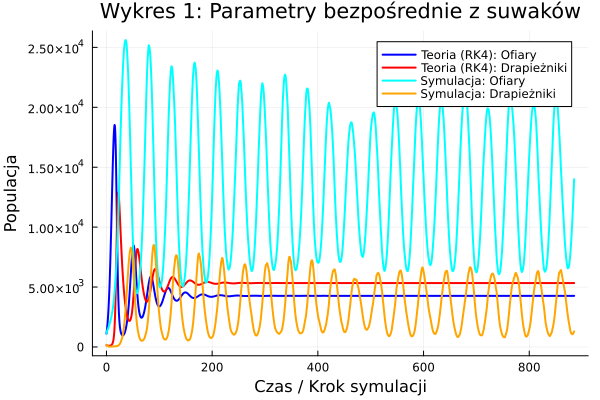

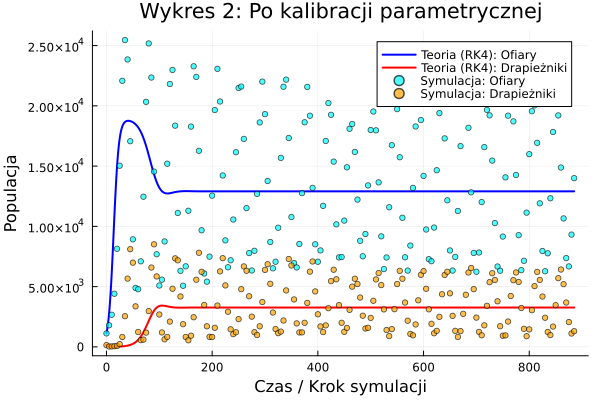

"wykres_parametry_wykalibrowane.png"

In [ ]:
punkty_zajace = history_points_time_prey[]
punkty_wilki  = history_points_time_pred[]

dane_zajace = [p[2] for p in punkty_zajace]
dane_wilki  = [p[2] for p in punkty_wilki]
czasy       = [p[1] for p in punkty_zajace]


# Zestaw A: Parametry czysto teoretyczne (z suwaków)
p_teoria = [
    0.3,                  # r
    (100 / 25) * 6400,      # (K/25)*6400
    0.3 / 6400,           # α/6400
    0.75 * (0.3 / 6400),  # b = 0.75*(α/6400)
    0.15                   # d
]

# Zestaw B: Parametry uzyskane po  kalibracji
p_kalibracja = [0.20552266666147775, 18976.69185932719, 2.012713102799738e-5, 1.5095348270998036e-5, 0.19484008242823317]

# Warunki początkowe (zgodne z symulatorem)
u0 = [dane_zajace[1], dane_wilki[1]] 
dt = 0.1
t_max = maximum(czasy) # Automatycznie dostosuje długość RK4 do długości symulacji

# Funkcja realizująca czysty algorytm RK4 dla zadanych parametrów
function rozwiaz_rk4(p, u0, t_max, dt)
    r, K, α, b, d = p
    
    # Funkcja zwracająca pochodne
    f(u) = [
        r * u[1] * (1.0 - u[1] / K) - α * u[1] * u[2],
        b * u[1] * u[2] - d * u[2]
    ]
    
    n_steps = round(Int, t_max / dt)
    
    # Inicjalizacja tablic wynikowych
    t_vec = zeros(n_steps + 1)
    prey_vec = zeros(n_steps + 1)
    pred_vec = zeros(n_steps + 1)
    
    u = copy(u0)
    t_vec[1] = 0.0
    prey_vec[1] = u[1]
    pred_vec[1] = u[2]
    
    # Pętla algorytmu RK4
    for i in 1:n_steps
        k1 = f(u)
        k2 = f(u + 0.5 * dt * k1)
        k3 = f(u + 0.5 * dt * k2)
        k4 = f(u + dt * k3)
        
        u = u + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
        t_vec[i+1] = i * dt
        prey_vec[i+1] = u[1]
        pred_vec[i+1] = u[2]
    end
    
    return t_vec, prey_vec, pred_vec
end

t_teoria, prey_teoria, pred_teoria = rozwiaz_rk4(p_teoria, u0, t_max, dt)
t_kalib, prey_kalib, pred_kalib   = rozwiaz_rk4(p_kalibracja, u0, t_max, dt)


# WYKRES 1: Parametry suwakowe (Teoretyczne) vs Symulacja
p1 = Plots.plot(t_teoria, prey_teoria, label="Teoria (RK4): Ofiary", color=:blue, linewidth=2)
Plots.plot!(p1, t_teoria, pred_teoria, label="Teoria (RK4): Drapieżniki", color=:red, linewidth=2)
# Pełne linie z symulacji
Plots.plot!(p1, czasy, dane_zajace, label="Symulacja: Ofiary", color=:cyan, linewidth=2)
Plots.plot!(p1, czasy, dane_wilki, label="Symulacja: Drapieżniki", color=:orange, linewidth=2)

Plots.title!(p1, "Wykres 1: Parametry bezpośrednie z suwaków")
Plots.xlabel!(p1, "Czas / Krok symulacji")
Plots.ylabel!(p1, "Populacja")



# WYKRES 2: Parametry zoptymalizowane (Wykalibrowane) vs Symulacja
p2 = Plots.plot(t_kalib, prey_kalib, label="Teoria (RK4): Ofiary", color=:blue, linewidth=2)
Plots.plot!(p2, t_kalib, pred_kalib, label="Teoria (RK4): Drapieżniki", color=:red, linewidth=2)
# Kropki co 10 kroków z symulacji
Plots.scatter!(p2, czasy[1:5:end], dane_zajace[1:5:end], label="Symulacja: Ofiary", color=:cyan, markersize=3, alpha=0.7)
Plots.scatter!(p2, czasy[1:5:end], dane_wilki[1:5:end], label="Symulacja: Drapieżniki", color=:orange, markersize=3, alpha=0.7)

Plots.title!(p2, "Wykres 2: Po kalibracji parametrycznej")
Plots.xlabel!(p2, "Czas / Krok symulacji")
Plots.ylabel!(p2, "Populacja")


display(p1)
display(p2)


# Opcjonalnie: Zapisanie wykresów do plików graficznych na slajdy
png(p1, "wykres_parametry_teoretyczne.png")
png(p2, "wykres_parametry_wykalibrowane.png")
